# What is Gradient Descent?

- It is and first-order optimization algorithm used to find the minimum of a differentiable function.

- We will understand it through the lens of Linear Regression, but it is used in many other algorithms as well like Logistic Regression, Neural Networks, etc.

# <span style="color: orange;">Intuition:</span>

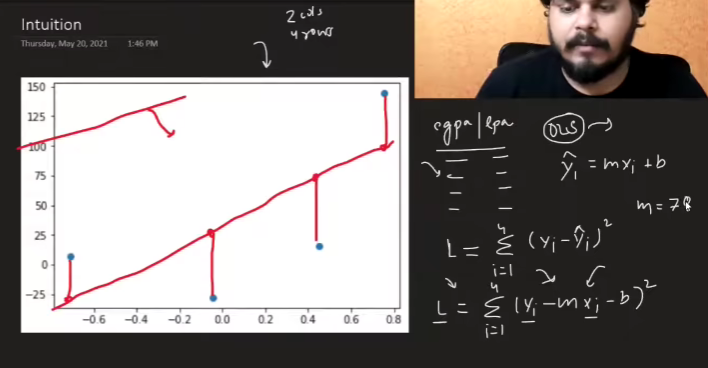

- We took 2 col, cgpa and package
- Now we want the best fit line, which means the residual in y-direction should be minimum.
- So our cost function is the sum of squares of residuals
- We want to minimize this cost function, by changing the tuning knobs (parameters) of the line, which are slope and intercept in this case.

- To keep our discussion simple let's say we know the value of $m = 78.35$ (by applying OLS)
- So now Cost function is only a function of $b$ (intercept), that is hum bss line ko upar niche kar skte hai
- So, hume ek esa hight chahiye for this line, jaha ye minimum galti kare (value of $$b$$ for which cost function is minimum)

- L (cost function) is varying in terms of $b^2$

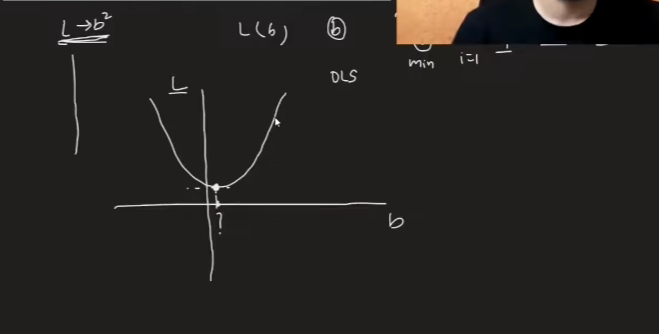

- So agar hum OLS lagate then, we would differentiate the cost function w.r.t $b$ and set it to 0 to find the minimum point and find the value of $b$.
- But we will not do this as higher dimension mei problem hoga, so we will use Gradient Descent.

## Steps of Gradient Descent:

1. Select a random $b$ (say $b = -10$)

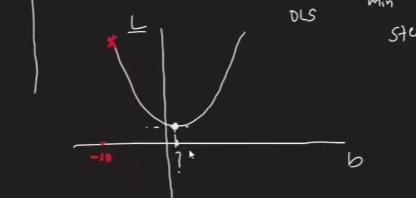

- So hume red marked point se start karna hai, and minimum cost function pe jana hai to get the correct value of $b$, by iteratively changing the value of $b$

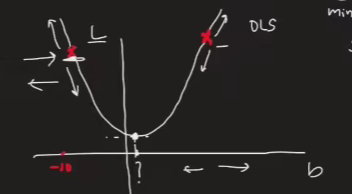

- Now kisi vhi point pe, we have 2 options, either to increase the value of $b$ or decrease the value of $b$ to reach the minimum point, but how do we know which direction to go?
    
    - AND THIS IS THE TRICK OF GRADIENT DESCENT,THAT ANSWERS THIS QUESTION (explained in the next point)

2. Find the slope of the cost function at that point (gradient)

    - If slope = -ve, increase $b$, to reach the minimum point
    - If slope = +ve, decrease $b$, to reach the minimum point

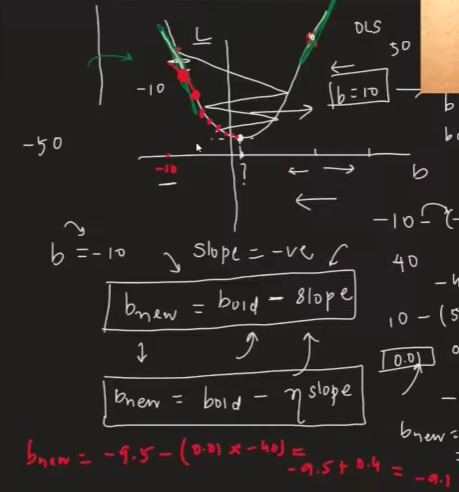

- A learning rate is multiplied to the slope to control the step size of each iteration,  otherwise jo picture mei white zig-zag line dikh rha hai, hum wese move karte


### Gradient Descent (Intuitive Form)

For any parameter:

$$
\text{new value} = \text{old value} - \text{learning rate} \times \text{slope}
$$

---

### For Intercept \(b\)

$$
b_{\text{new}} = b_{\text{old}} - \alpha \frac{\partial J}{\partial b}
$$

## When to stop the iterations?

1. Find difference in $b_{\text{old}}$ and $b_{\text{new}}$, if it is less than a threshold value, stop the iterations

2. Some times we limit the number of iterations to a fixed number, say 1000, and stop the iterations after that

<span style="color: red;">(These iterations is known as **epochs**)</span> 

# <span style="color: orange;">Mathematical Formulation of Gradient Descent:</span>

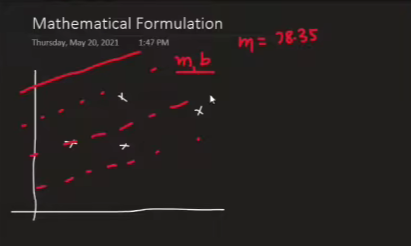

- Let's say we know the value of $m$ , so we need to find the value of $b$ to minimize the cost function using gradient descent

## Gradient Descent w.r.t Intercept $b$ (Slope $m$ is fixed)

---

### Step 1: Model

$$
\hat{y}_i = m x_i + b
$$

(where $m$ is constant)

---

### Step 2: Loss Function

$$
L = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

$$
L = \sum_{i=1}^{n} (y_i - m x_i - b)^2
$$

---

### Step 3: Gradient w.r.t $b$

$$
\frac{\partial L}{\partial b}
= \frac{\partial}{\partial b} \left( \sum_{i=1}^{n} (y_i - m x_i - b)^2 \right)
$$

Using chain rule:

$$
= 2 \sum_{i=1}^{n} (y_i - m x_i - b)(-1)
$$

$$
= -2 \sum_{i=1}^{n} (y_i - m x_i - b)
$$

---

### Step 4: Update Rule

$$
b_{\text{new}} = b_{\text{old}} - \eta \left. \frac{\partial L}{\partial b} \right|_{b = b_{\text{old}}}
$$

Substitute gradient:

$$
b_{\text{new}} = b_{\text{old}} - \eta \left(-2 \sum_{i=1}^{n} (y_i - m x_i - b)\right)
$$

$$
b_{\text{new}} = b_{\text{old}} + 2\eta \sum_{i=1}^{n} (y_i - m x_i - b)
$$

---

### Final Intuition

$$
b_{\text{new}} = b_{\text{old}} - \eta \times \text{slope}
$$

- Let's now understand using code example:

In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

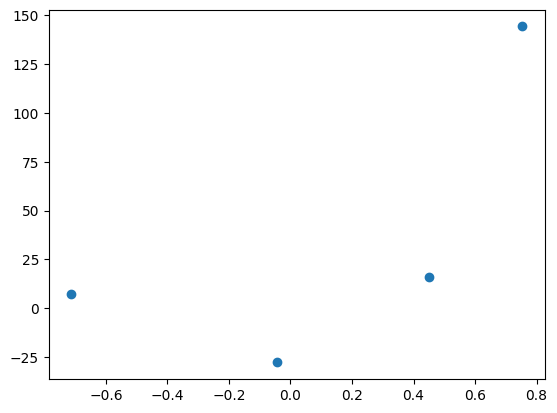

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [4]:
# Lets apply OLS
from sklearn.linear_model import LinearRegression

In [5]:
reg = LinearRegression()
reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
reg.coef_

array([78.35063668])

In [7]:
reg.intercept_

np.float64(26.15963284313262)

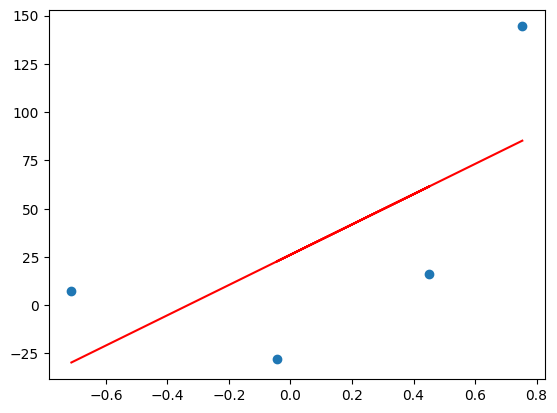

In [8]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

In [12]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35 * X) + 0).reshape(4) # We have b =0, and m so we can plot the line (though it is not the best fit line)

In [ ]:
(78.35 * X) + 100 # we reshaped it in y_pred to make it 1D array, so we can plot it. We can see that the line is not the best fit line

array([[ 44.18419163],
       [135.39949674],
       [ 96.51318381],
       [159.05759577]])

In [ ]:
t = (78.35 * X) + 100 # just experimenting 

In [17]:
t.ndim

2

In [16]:
t.shape

(4, 1)

In [23]:
t.reshape(4,1,1)

array([[[ 44.18419163]],

       [[135.39949674]],

       [[ 96.51318381]],

       [[159.05759577]]])

# Reshaping Tensors (NumPy)

---

## Current Tensor

If:
$$
t.\text{shape} = (4,1)
$$

Then total elements:
$$
4 \times 1 = 4
$$

---

## Golden Rule

$$
\text{Total elements must remain constant}
$$

$$
\text{new shape product} = \text{old shape product}
$$

---

## Possible Reshapes

### 1. Flatten (1D)
```python
t.reshape(4)
t.reshape(-1)
```
Shape:
$$
(4,)
$$

---

### 2. Row Vector
```python
t.reshape(1, 4)
```
Shape:
$$
(1,4)
$$

---

### 3. Column Vector
```python
t.reshape(4, 1)
```
Shape:
$$
(4,1)
$$

---

### 4. Using Auto Inference
```python
t.reshape(-1, 1)
t.reshape(1, -1)
```

---

## Useful Functions

### Flatten
```python
t.flatten()
t.ravel()
```

### Remove single dimensions
```python
t.squeeze()
```
$$
(4,1) \rightarrow (4,)
$$

---

## How to Think

### Step 1: Count elements
$$
\text{total elements} = 4
$$

### Step 2: Decide structure

| Goal | Shape |
|------|------|
| List | $(4,)$ |
| Column vector | $(4,1)$ |
| Row vector | $(1,4)$ |

---

### Step 3: Use `-1` for convenience

```python
t.reshape(-1)
t.reshape(1, -1)
```

---

## Important Note

Reshape does NOT change data, only arrangement.

$$
\text{Same data, different structure}
$$

---

## Invalid Example

```python
t.reshape(3,2)
```

$$
3 \times 2 = 6 \neq 4
$$

❌ Not allowed

In [13]:
y_pred

array([-55.81580837,  35.39949674,  -3.48681619,  59.05759577])

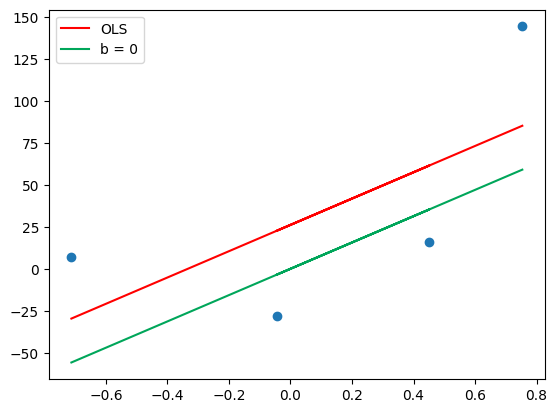

In [24]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()

In [25]:
m = 78.35
b = 0

loss_slope = -2 * np.sum(y - m*X.ravel() - b) # This is the slope of the loss funcn wrt b
loss_slope

np.float64(-209.27763408209216)

- step sizre = learning rate * slope

In [26]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [27]:
# Calculating the new intercept
b = b - step_size
b

np.float64(20.927763408209216)

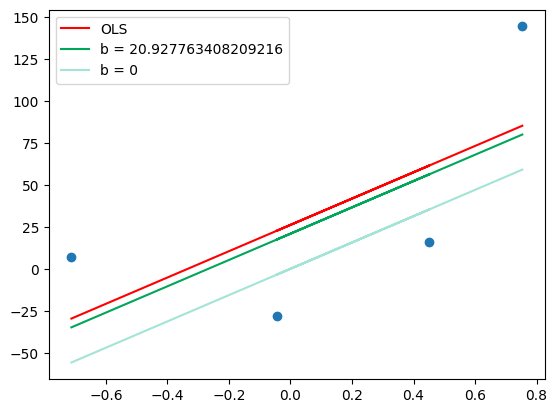

In [28]:
y_pred1 = ((78.35 * X) + b).reshape(4) # plotting line with new b

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [29]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-41.85552681641843)

In [30]:
step_size = loss_slope*lr
step_size

np.float64(-4.185552681641844)

In [ ]:
b = b - step_size
b # remember the correct b = 26.159, so we are getting closer to the correct b

np.float64(25.11331608985106)

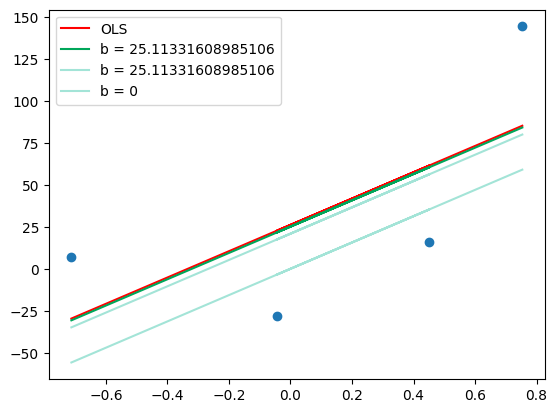

In [32]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [33]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-8.371105363283675)

In [ ]:
step_size = loss_slope*lr
step_size # step size is getting smaller, as we are getting closer to the minimum

np.float64(-0.8371105363283675)

In [ ]:
b = b - step_size
b # remember the correct b = 26.159, so we are getting closer to the correct b

np.float64(25.95042662617943)

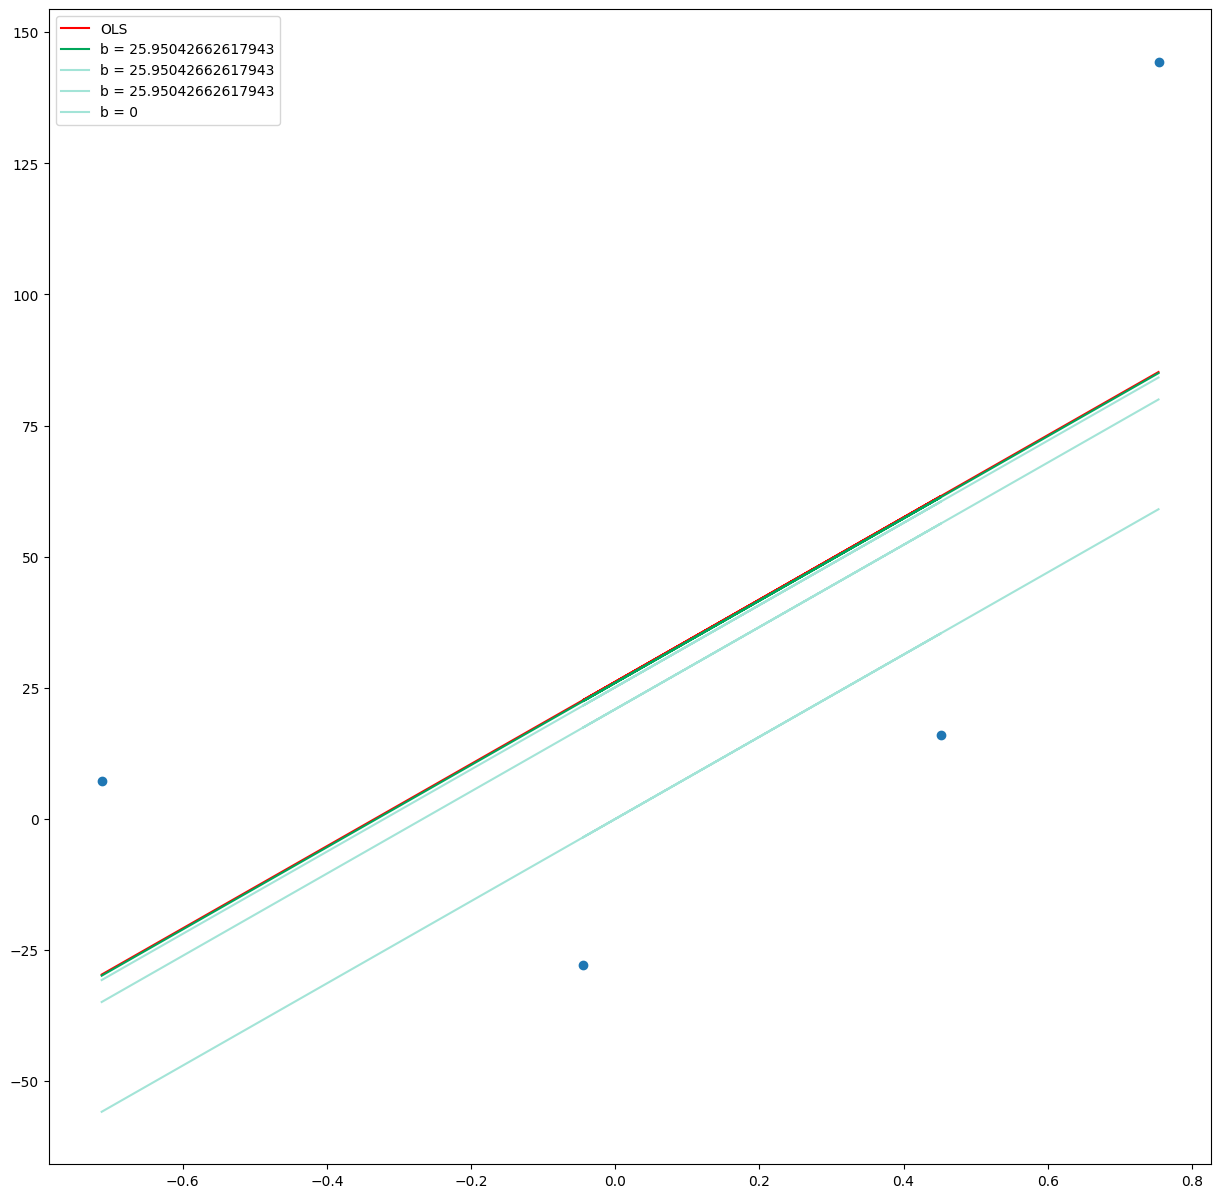

In [36]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

Convergence reached at epoch 65


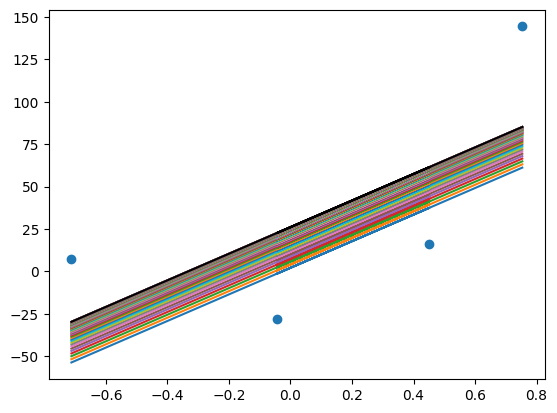

In [44]:
b = 0
m = 78.35
lr = 0.01

epochs = 100

for i in range(epochs):

  b_old = b
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)
  
  y_pred = m * X + b

  if(abs(b - b_old) < 0.01):
    print('Convergence reached at epoch {}'.format(i))
    plt.plot(X,y_pred,color="#000000",label='b = {}'.format(b))
    break

  plt.plot(X,y_pred)


plt.scatter(X,y)

- Now go to the 2_creating-our-own-class-gd.ipynb and see how to implement our own class for caluclating $b$ using gradient descent, later on we will see how to calculate both $m$ and $b$ using gradient descent